In [1]:
import scanpy as sc
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
import numpy as np
import os
import re

In [2]:
import scipy.io


In [3]:
# try import the data

dir = "/rds/general/user/ztb25/home/count_output/"

# read manually
matrix = scipy.io.mmread("/rds/general/user/ztb25/home/count_output/matrix.mtx.gz").T.tocsr()
barcodes = pd.read_csv("/rds/general/user/ztb25/home/count_output/barcodes.tsv.gz", header=None)[0].values
features = pd.read_csv("/rds/general/user/ztb25/home/count_output/features.tsv.gz", header=None)[0].values

# create anndata
adata = sc.AnnData(X=matrix)
adata.obs_names = barcodes
adata.var_names = features
adata.var_names_make_unique()

print(adata)

AnnData object with n_obs × n_vars = 631395 × 28177


In [4]:
features = pd.read_csv("/rds/general/user/ztb25/home/count_output/features.tsv.gz", sep="\t", header=None)


In [5]:
print(features.head())


          0
0      GNLY
1   ARFGEF2
2  ARHGAP30
3     ODF2L
4   MT-RNR2


In [6]:
print(features.shape)

(28177, 1)


In [7]:
print(adata)

AnnData object with n_obs × n_vars = 631395 × 28177


In [8]:
display(adata.obs.head())
display(adata.var.head()) 

""
AACATTCCTC
TGGTTCCACTCATCATGACC
GTATTCTATGGCTCTACATA
GTATTCTATG
GGCACCTTGCGCTGCTCTTC


""
GNLY
ARFGEF2
ARHGAP30
ODF2L
MT-RNR2


In [9]:
adata.obs_names.str.len().value_counts()


20    624758
10      6637
dtype: int64

In [10]:
pd.DataFrame(
    adata.X[:10, :20].toarray(),
    index=adata.obs_names[:10],
    columns=adata.var_names[:20]
)

,GNLY,ARFGEF2,ARHGAP30,ODF2L,MT-RNR2,CREBZF,PANK2,HEXA,MAP2K2,PLCG1,EIF3A,VIM,RPS27,FAM107B,UBA52,JUN,POMP,B2M,MCL1,ENSG00000260669
AACATTCCTC,386,7,71,27,1054,15,15,9,14,19,113,153,651,44,122,210,62,1319,61,26
TGGTTCCACTCATCATGACC,424,6,70,27,1361,13,7,17,12,10,83,118,749,39,109,185,57,1648,49,22
GTATTCTATGGCTCTACATA,672,12,95,51,2071,15,22,24,9,13,116,188,1185,65,156,265,75,2619,73,27
GTATTCTATG,190,5,30,12,646,3,3,9,4,5,43,51,345,13,50,74,20,856,18,12
GGCACCTTGCGCTGCTCTTC,577,8,106,23,1885,5,7,12,8,12,116,176,1031,42,163,246,85,2265,70,32
GCCGGTAGCGAGGTATAGAC,529,5,83,30,1599,13,13,18,7,10,96,172,929,44,132,219,57,1967,64,30
GCCGTCGAGAACATGCCTGT,293,2,57,16,910,12,6,10,7,8,57,90,493,25,87,118,39,1100,31,17
GCGCACCAGGGCATTGGCGC,558,7,88,26,1616,8,11,14,16,18,117,150,946,56,140,240,69,2004,59,37
GCAATGATCAAGCGAGAGCT,596,15,86,25,1864,10,17,22,9,16,106,159,1044,40,155,227,72,2324,67,32
CGTCTCAGACACGCATTGCA,1464,17,252,63,4803,32,30,46,20,28,290,455,2643,108,414,553,193,6067,156,79


In [11]:
total_elements = adata.X.shape[0] * adata.X.shape[1]
nonzero = adata.X.nnz
print(f"Sparsity: {1 - nonzero/total_elements:.2%} zeros")

Sparsity: 99.62% zeros


In [13]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-") 
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [14]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 631395 × 28177
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

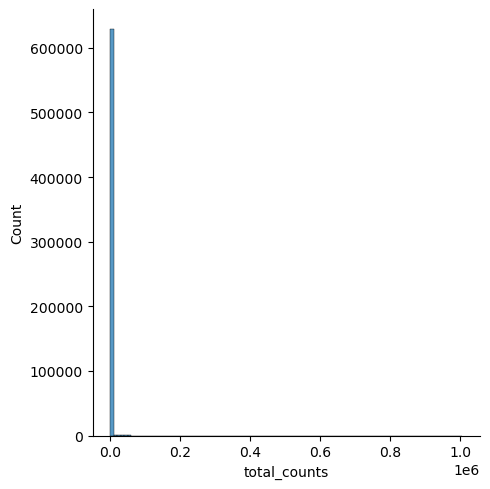

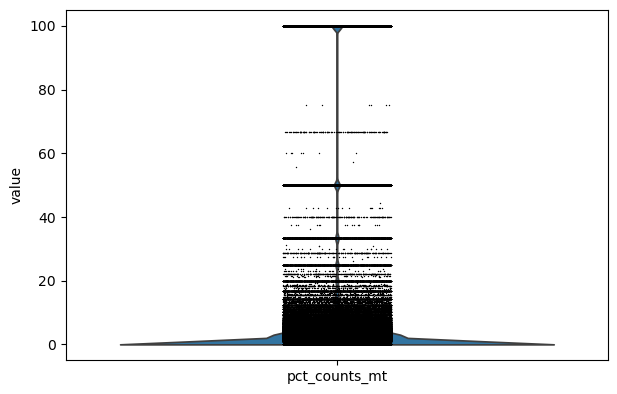

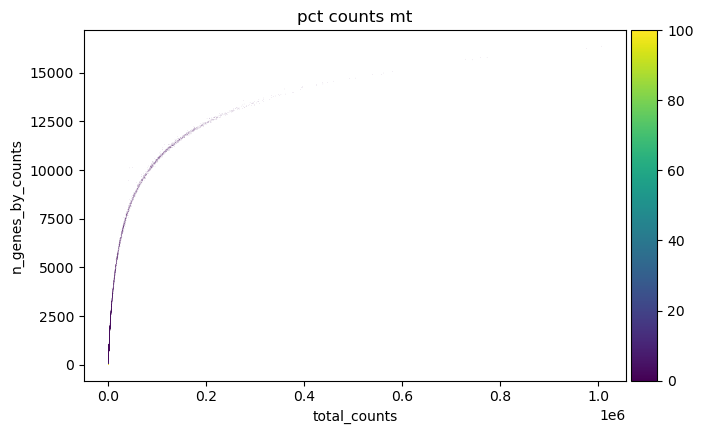

In [15]:
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")